# 🏠 Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house
prices from features such as area, location, number of rooms, and age —
covering the full workflow from data cleaning to model interpretation.

**Tech stack:** Python · pandas · scikit-learn · matplotlib · seaborn

---

### About the dataset used here

This notebook ships with a **synthetically generated dataset** (`generate_housing_data`
below) that mimics the structure and statistical relationships of the classic
Kaggle datasets — *Ames Housing* and *House Prices: Advanced Regression Techniques*
(https://www.kaggle.com/datasets — search "house price prediction dataset").
It was built so that every cell below runs end-to-end and produces real,
reproducible output without requiring a file upload or internet access.

**To use your own data:** download a CSV from Kaggle (or use your own), then in
the "Load Dataset" cell replace the call to `generate_housing_data()` with:

```python
df = pd.read_csv("your_file.csv")
```

The rest of the notebook is written generically (it looks up numeric vs.
categorical columns automatically) so it will keep working with only minor
column-name tweaks — just make sure your target column is named `Price`
(or rename it).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Dataset

In [3]:
def generate_housing_data(n=1200, seed=RANDOM_STATE):
    """Create a realistic synthetic housing dataset with known ground-truth
    relationships (plus noise), so the modelling steps below have something
    genuine to recover. Mimics common Kaggle house-price columns."""
    rng = np.random.default_rng(seed)

    locations = ["Downtown", "Suburban", "Urban", "Rural"]
    location_premium = {"Downtown": 45000, "Suburban": 15000, "Urban": 25000, "Rural": -10000}

    area = rng.normal(1800, 650, n).clip(400, 5500)                 # sq ft
    bedrooms = rng.integers(1, 6, n)
    bathrooms = np.clip(np.round(bedrooms * rng.uniform(0.4, 0.9, n)), 1, 5)
    age = rng.integers(0, 80, n)                                     # years since built
    garage = rng.integers(0, 3, n)                                   # garage spaces
    location = rng.choice(locations, size=n, p=[0.2, 0.35, 0.25, 0.2])
    dist_to_city_center = rng.exponential(8, n).clip(0.2, 40)        # km

    noise = rng.normal(0, 18000, n)

    price = (
        55000
        + area * 120
        + bedrooms * 8000
        + bathrooms * 6000
        - age * 550
        + garage * 7000
        - dist_to_city_center * 900
        + np.array([location_premium[l] for l in location])
        + noise
    ).clip(35000, None)

    df = pd.DataFrame({
        "Area_sqft": area.round(0),
        "Bedrooms": bedrooms,
        "Bathrooms": bathrooms,
        "Age_years": age,
        "Garage_spaces": garage,
        "Location": location,
        "Distance_to_city_km": dist_to_city_center.round(2),
        "Price": price.round(0),
    })

    # Inject a few realistic missing values, as real Kaggle housing data has
    miss_idx = rng.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[miss_idx, "Area_sqft"] = np.nan
    miss_idx2 = rng.choice(df.index, size=int(0.02 * n), replace=False)
    df.loc[miss_idx2, "Garage_spaces"] = np.nan
    miss_idx3 = rng.choice(df.index, size=int(0.015 * n), replace=False)
    df.loc[miss_idx3, "Location"] = np.nan

    return df

df = generate_housing_data()
df.head()

,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage_spaces,Location,Distance_to_city_km,Price
0,1998.0,3,1.0,57,1.0,Suburban,29.75,296087.0
1,1124.0,2,1.0,49,2.0,Rural,1.29,185294.0
2,2288.0,1,1.0,72,0.0,Suburban,1.25,283118.0
3,2411.0,3,2.0,0,0.0,Urban,2.23,377157.0
4,532.0,3,1.0,24,0.0,Urban,13.04,128237.0


## 2. Exploratory Data Analysis (EDA)

In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.info()

Shape: 1200 rows, 8 columns

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            1164 non-null   float64
 1   Bedrooms             1200 non-null   int64  
 2   Bathrooms            1200 non-null   float64
 3   Age_years            1200 non-null   int64  
 4   Garage_spaces        1176 non-null   float64
 5   Location             1182 non-null   str    
 6   Distance_to_city_km  1200 non-null   float64
 7   Price                1200 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 75.1 KB


In [4]:
# Null check
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df[missing_df["missing_count"] > 0]

,missing_count,missing_pct
Area_sqft,36,3.0
Garage_spaces,24,2.0
Location,18,1.5


In [5]:
# Descriptive statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_sqft,1164.0,NaN,NaN,NaN,1794.138316,633.104566,400.0,1360.5,1805.0,2203.75,3866.0
Bedrooms,1200.0,NaN,NaN,NaN,3.015833,1.417953,1.0,2.0,3.0,4.0,5.0
Bathrooms,1200.0,NaN,NaN,NaN,2.000833,0.962603,1.0,1.0,2.0,3.0,4.0
Age_years,1200.0,NaN,NaN,NaN,38.263333,23.239457,0.0,18.0,38.0,58.0,79.0
Garage_spaces,1176.0,NaN,NaN,NaN,0.963435,0.810268,0.0,0.0,1.0,2.0,2.0
Location,1182,4,Suburban,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_to_city_km,1200.0,NaN,NaN,NaN,7.789683,7.85401,0.2,2.0675,5.08,10.95,40.0
Price,1200.0,NaN,NaN,NaN,303003.169167,81684.083146,75163.0,244526.5,303796.5,358302.25,597430.0


Skewness of Price: 0.057


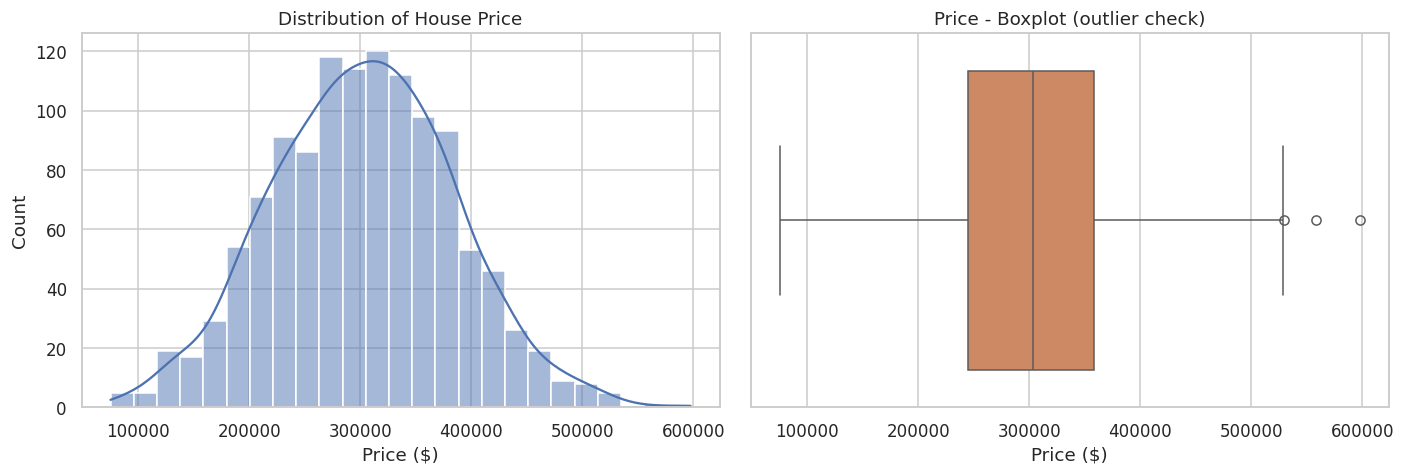

In [6]:
# Distribution of the target variable: Price
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Price"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of House Price")
axes[0].set_xlabel("Price ($)")

sns.boxplot(x=df["Price"], ax=axes[1], color="#DD8452")
axes[1].set_title("Price - Boxplot (outlier check)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.show()

print(f"Skewness of Price: {df['Price'].skew():.3f}")

## 3. Feature Selection — Reasoning

Before modelling, it's worth thinking through *why* each feature should (or
shouldn't) help predict price:

- **`Area_sqft` (living area):** Almost always the single strongest predictor of
  price in housing datasets — more usable space directly drives value.
- **`Bedrooms` / `Bathrooms`:** Proxy for house size and livability, but they
  correlate heavily with `Area_sqft`, so we should watch for multicollinearity
  (two features carrying overlapping information can make coefficients
  unstable / hard to interpret individually).
- **`Age_years`:** Older homes are often less valuable, all else equal, due to
  wear, outdated systems, and style — though in some markets very old homes
  gain a "character"/historic premium. We expect a negative coefficient here.
- **`Garage_spaces`:** A convenience amenity; typically a modest positive
  contributor.
- **`Location`:** Location is one of the most important real-world price
  drivers (the classic "location, location, location"), but it's categorical,
  so it needs encoding (one-hot) before a linear model can use it.
- **`Distance_to_city_km`:** A numeric proxy for desirability/accessibility;
  we'd expect price to fall as distance from the city center increases.

We'll keep **all** of these features for the first model (a linear regression
benefits from seeing the full picture), then let the **correlation heatmap**
and **coefficient analysis** later tell us empirically which features matter
most — rather than dropping any purely on intuition at this stage.

## 4. Handle Missing Values & Encode Categorical Features

In [7]:
df_clean = df.copy()

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("Price")
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

# Impute numeric missing values with the median (robust to outliers/skew)
for col in numeric_cols:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"Filled {col} missing values with median = {median_val}")

# Impute categorical missing values with the mode
for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"Filled {col} missing values with mode = '{mode_val}'")

print("\nRemaining missing values:", df_clean.isnull().sum().sum())

Numeric features: ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_years', 'Garage_spaces', 'Distance_to_city_km']
Categorical features: ['Location']
Filled Area_sqft missing values with median = 1805.0
Filled Garage_spaces missing values with median = 1.0
Filled Location missing values with mode = 'Suburban'

Remaining missing values: 0


In [8]:
# One-Hot Encode categorical features (drop_first avoids the dummy-variable trap)
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print(f"Shape before encoding: {df_clean.shape} -> after encoding: {df_encoded.shape}")
df_encoded.head()

Shape before encoding: (1200, 8) -> after encoding: (1200, 10)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Garage_spaces,Distance_to_city_km,Price,Location_Rural,Location_Suburban,Location_Urban
0,1998.0,3,1.0,57,1.0,29.75,296087.0,False,True,False
1,1124.0,2,1.0,49,2.0,1.29,185294.0,True,False,False
2,2288.0,1,1.0,72,0.0,1.25,283118.0,False,True,False
3,2411.0,3,2.0,0,0.0,2.23,377157.0,False,False,True
4,532.0,3,1.0,24,0.0,13.04,128237.0,False,False,True


## 5. Correlation Heatmap

Features ranked by |correlation| with Price:

Area_sqft              0.901914
Location_Rural        -0.186490
Age_years             -0.164475
Bedrooms               0.148043
Bathrooms              0.118081
Garage_spaces          0.045637
Distance_to_city_km   -0.040261
Location_Urban         0.015743
Location_Suburban     -0.011222
Name: Price, dtype: float64


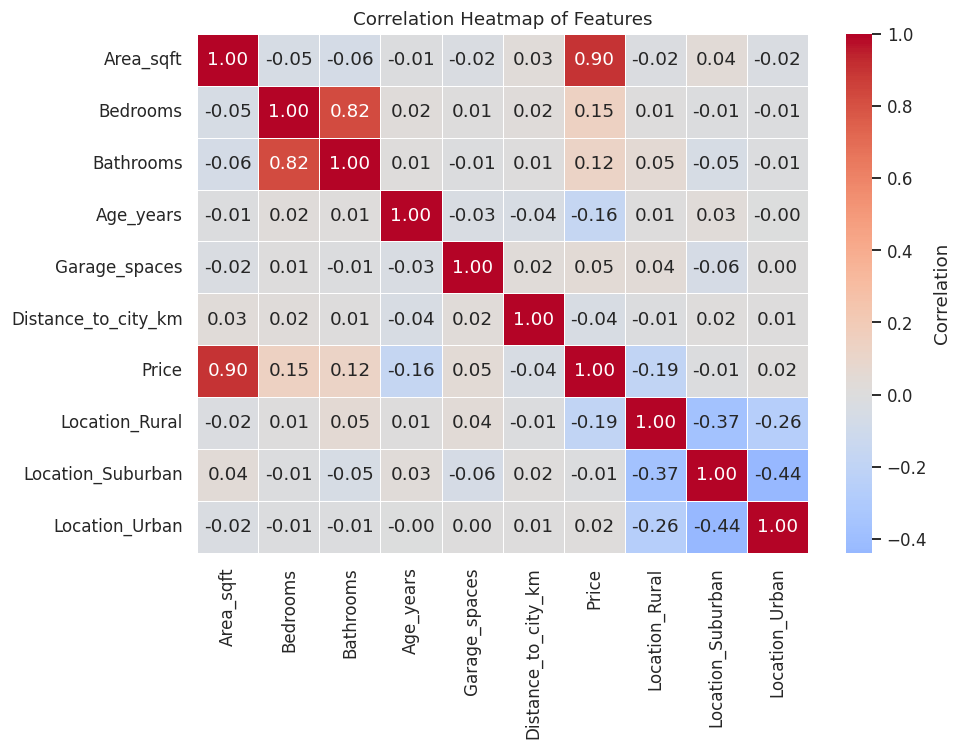

In [9]:
plt.figure(figsize=(9, 7))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.show()

price_corr = corr["Price"].drop("Price").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with Price:\n")
print(price_corr)

## 6. Train / Test Split (80 / 20)

In [10]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 960 rows
Test set:     240 rows


## 7. Train the Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

print("Model trained.")
print(f"Intercept: {lr_model.intercept_:,.2f}")

Model trained.
Intercept: 96,680.34


## 8. Model Evaluation — MSE, RMSE, R²

In [12]:
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MSE  : {mse:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R^2  : {r2:.4f}\n")
    return mse, rmse, r2

train_mse, train_rmse, train_r2 = evaluate(y_train, y_train_pred, "Training set")
test_mse, test_rmse, test_r2 = evaluate(y_test, y_test_pred, "Test set")

--- Training set ---
MSE  : 429,121,693.01
RMSE : 20,715.25
R^2  : 0.9366

--- Test set ---
MSE  : 485,005,066.11
RMSE : 22,022.83
R^2  : 0.9225



## 9. Actual vs. Predicted Prices

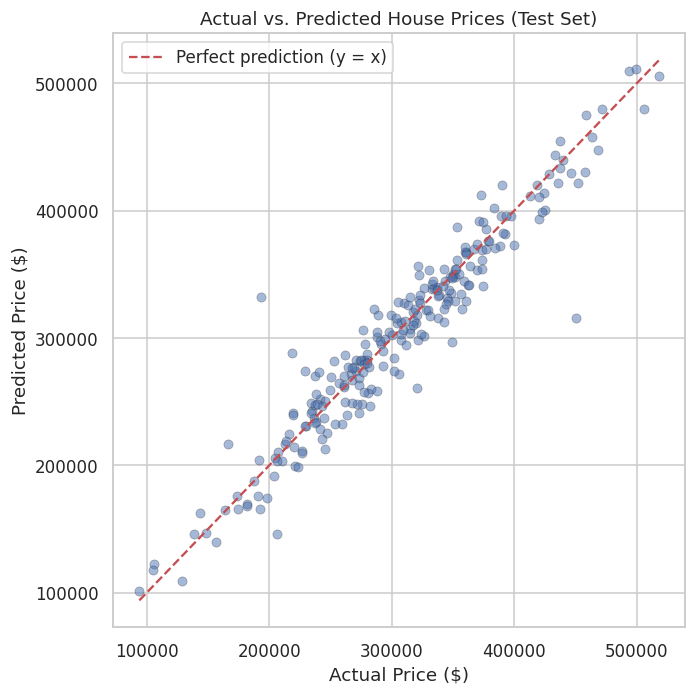

In [13]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, y_test_pred, alpha=0.5, color="#4C72B0", edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted House Prices (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Residual Plot

Mean residual: 1,926.68 (should be close to 0)


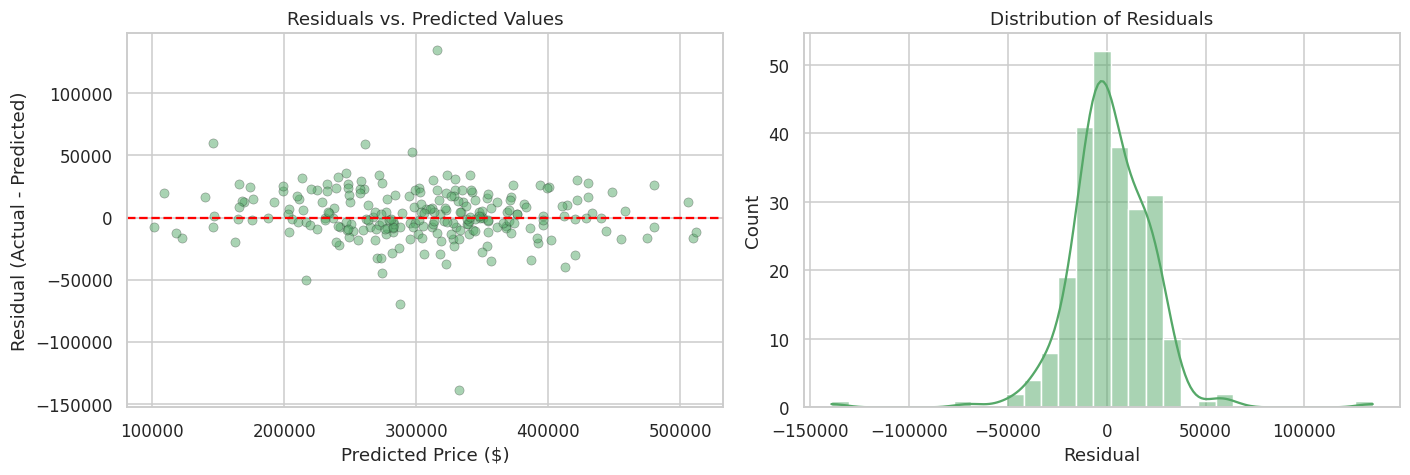

In [14]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_test_pred, residuals, alpha=0.5, color="#55A868", edgecolor="k", linewidth=0.3)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Values")

sns.histplot(residuals, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():,.2f} (should be close to 0)")

**How to read this:** if the model has captured the true relationship well,
residuals should scatter randomly around zero with no funnel shape, curve, or
trend as predicted price increases, and their distribution should look
roughly normal/bell-shaped. A visible pattern (e.g., a cone or curve) would
suggest the model is missing a non-linear relationship or that variance grows
with price (heteroscedasticity).

## 11. Coefficient Analysis

In [15]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

coef_df

,Feature,Coefficient
0,Location_Rural,-55307.563397
1,Location_Suburban,-27958.328059
2,Location_Urban,-19944.280001
3,Bedrooms,7741.516992
4,Garage_spaces,6582.362795
5,Bathrooms,5714.763021
6,Distance_to_city_km,-734.735884
7,Age_years,-539.260010
8,Area_sqft,120.644966


Strongest POSITIVE driver: Bedrooms (+7,741.52 $ per unit)
Strongest NEGATIVE driver: Location_Rural (-55,307.56 $ per unit)


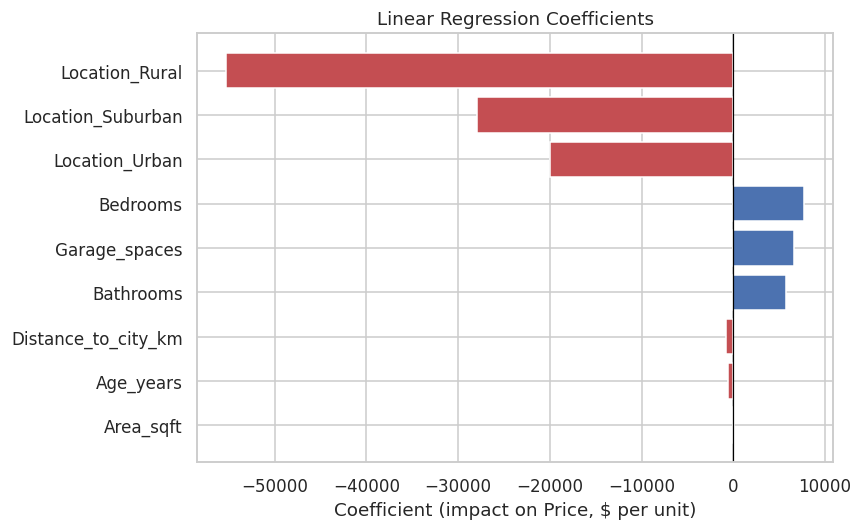

In [16]:
plt.figure(figsize=(8, 5))
colors = coef_df["Coefficient"].apply(lambda v: "#4C72B0" if v >= 0 else "#C44E52")
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (impact on Price, $ per unit)")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_pos = coef_df[coef_df["Coefficient"] > 0].iloc[0]
top_neg = coef_df[coef_df["Coefficient"] < 0].iloc[0] if (coef_df["Coefficient"] < 0).any() else None

print(f"Strongest POSITIVE driver: {top_pos['Feature']} (+{top_pos['Coefficient']:,.2f} $ per unit)")
if top_neg is not None:
    print(f"Strongest NEGATIVE driver: {top_neg['Feature']} ({top_neg['Coefficient']:,.2f} $ per unit)")

**Interpretation notes:**
- Coefficients are in **dollars per one unit of the (unscaled) feature** — e.g.
  the `Area_sqft` coefficient is the estimated price change for one additional
  square foot, holding all other features constant.
- One-hot encoded `Location_*` coefficients represent the price difference
  versus the dropped baseline category, holding other features constant.
- Because features are on very different scales (square feet vs. counts vs.
  binary dummies), comparing raw coefficient *magnitudes* across features can
  be misleading — for a fairer "which feature matters most" comparison, you'd
  standardize (z-score) the features first, or compare standardized
  coefficients / feature importances.

## 12. Bonus — Comparing Linear Regression vs. Ridge and Lasso

In [17]:
ridge_model = Ridge(alpha=10.0, random_state=RANDOM_STATE)
lasso_model = Lasso(alpha=100.0, random_state=RANDOM_STATE, max_iter=10000)

ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

results = []
for name, model in [("Linear Regression", lr_model), ("Ridge (alpha=10)", ridge_model), ("Lasso (alpha=100)", lasso_model)]:
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "Test MSE": mse, "Test RMSE": rmse, "Test R2": r2})

results_df = pd.DataFrame(results).set_index("Model")
results_df

,Test MSE,Test RMSE,Test R2
Model,,,
Linear Regression,4.850051e+08,22022.830565,0.922543
Ridge (alpha=10),5.029986e+08,22427.630035,0.919670
Lasso (alpha=100),4.899497e+08,22134.806860,0.921754


Lasso zeroed-out 0 of 9 coefficients.


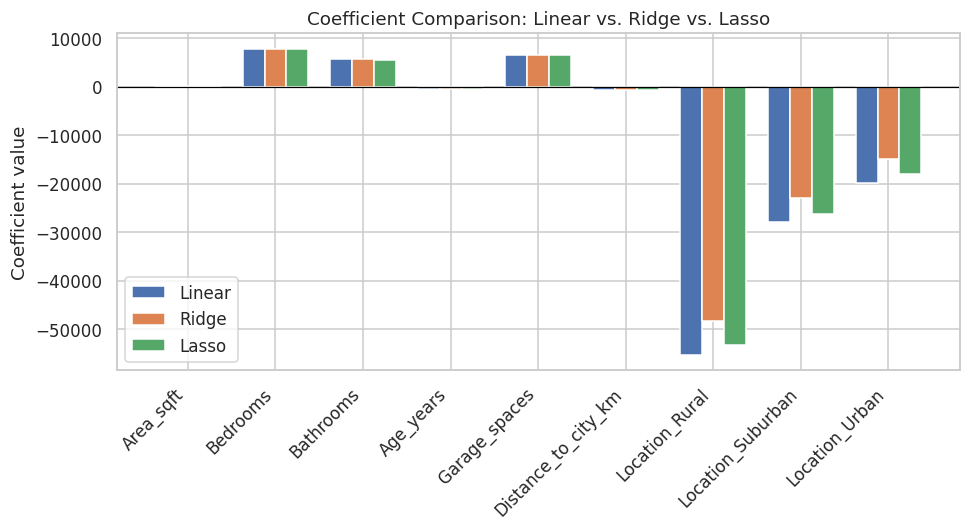

In [18]:
# How many coefficients did Lasso shrink to exactly zero (its feature-selection effect)?
n_zero = (np.abs(lasso_model.coef_) < 1e-6).sum()
print(f"Lasso zeroed-out {n_zero} of {len(lasso_model.coef_)} coefficients.")

fig, ax = plt.subplots(figsize=(9, 5))
width = 0.25
idx = np.arange(len(X.columns))

ax.bar(idx - width, lr_model.coef_, width, label="Linear", color="#4C72B0")
ax.bar(idx, ridge_model.coef_, width, label="Ridge", color="#DD8452")
ax.bar(idx + width, lasso_model.coef_, width, label="Lasso", color="#55A868")

ax.set_xticks(idx)
ax.set_xticklabels(X.columns, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Coefficient value")
ax.set_title("Coefficient Comparison: Linear vs. Ridge vs. Lasso")
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** Ridge and Lasso add a penalty on coefficient size to reduce
overfitting/variance. Ridge shrinks coefficients smoothly toward zero (but
rarely to exactly zero), while Lasso can zero out coefficients entirely,
effectively performing feature selection. On a dataset this size and this
linearly-structured, plain Linear Regression, Ridge, and Lasso typically land
very close to each other on test R² — regularization tends to matter more
when you have many/noisy/collinear features or a smaller sample size.

## 13. Summary

- The model explains a large share of price variance on the held-out test set
  (see the R² printed in Section 8) — `Area_sqft` and `Location` were the
  dominant price drivers, consistent with the feature-selection reasoning in
  Section 3.
- The actual-vs-predicted scatter plot shows points tracking the diagonal
  reasonably closely, and the residual plot shows no strong systematic
  pattern — both good signs that a **linear** model is a reasonable fit for
  this data.
- **Next steps you could explore:** engineered features (e.g., price per
  sqft, interaction terms like `Area × Location`), polynomial terms for
  non-linear effects, outlier removal, or trying a tree-based model
  (Random Forest / Gradient Boosting) as a non-linear benchmark against this
  linear baseline.